# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://riskfolio-lib.readthedocs.io/en/latest/)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__
## Tutorial 55: Mean Even Moment of Order 2p Optimization

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'AMZN', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'AAPL', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SEE', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].iloc[-300:,:].pct_change().dropna()

display(Y.head())

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-19,1.5230%,-0.3778%,0.0475%,-0.8599%,-1.4332%,-3.0011%,0.1113%,1.2968%,3.4360%,-0.8763%,...,0.5122%,0.1475%,0.6339%,-0.1823%,-0.7728%,1.1385%,-1.1145%,-1.2872%,0.4575%,-0.8025%
2018-10-22,0.6111%,1.4325%,-1.9240%,-0.0786%,-0.6335%,-6.2983%,-0.6392%,-1.1024%,0.0528%,-0.3221%,...,-0.1491%,0.8927%,-0.8661%,0.4483%,-2.8972%,-0.6085%,-0.6075%,-0.8634%,0.1457%,-3.4490%
2018-10-23,0.9426%,-1.1513%,-3.6571%,-1.6658%,-0.4201%,-0.4521%,-0.2797%,-0.5034%,0.1844%,-3.9948%,...,-0.3112%,-1.3956%,0.4766%,-5.1240%,-0.0320%,1.0713%,-1.0807%,-1.8308%,4.0560%,4.0353%
2018-10-24,-3.4302%,-5.9083%,-4.5500%,1.3141%,-1.8042%,-3.5933%,-4.2917%,0.8673%,0.9995%,-4.1109%,...,-3.6334%,-5.3469%,3.5178%,-4.2683%,-1.3479%,-8.0557%,-1.2403%,-4.2187%,0.3671%,-3.3065%
2018-10-25,2.1898%,7.0887%,0.4741%,2.5716%,0.5186%,0.7782%,5.0410%,-0.5733%,-1.1719%,2.1585%,...,5.8824%,5.8444%,-1.0309%,0.4913%,0.9109%,-1.2516%,4.3662%,1.3800%,-1.7241%,3.3538%


## 2. Estimating Mean - Even Moment of order 2p Portfolios

The Even Moment of order 2p portfolio model proposed by __[Cajas (2026)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6518258)__ shows how to optimize the even moments of portfolio returns using sample data. 

### 2.1 Calculating the portfolio that optimize return/ even moment of order 2p ratio.

In [3]:
import riskfolio as rp
import mosek

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimum portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu,
                  method_cov=method_cov,
                  )

# Estimate optimal portfolio:

port.solvers = ['MOSEK'] # It is recommended to use mosek when optimizing Semi Kurtosis
port.p_em = 4 # p of the order 2 * p_em of the Even Moment

model ='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'EM' # Risk measure used, this time will be Even Moment
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,8.1902%,0.0000%,0.0000%,4.6160%,0.0000%,...,35.5802%,0.0000%,0.0001%,0.0000%,9.9824%,1.5814%,2.3931%,0.0000%,26.1135%,0.0000%


### 2.2 Plotting portfolio composition

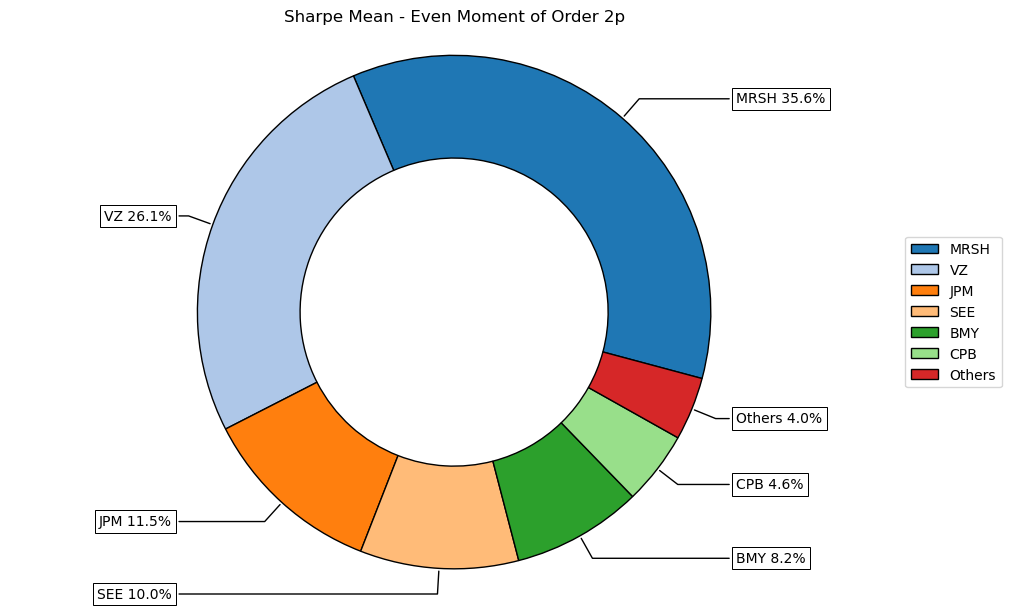

In [4]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w,
                 title='Sharpe Mean - Even Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap = "tab20",
                 height=6,
                 width=10,
                 ax=None)

### 2.3 Plotting risk measures

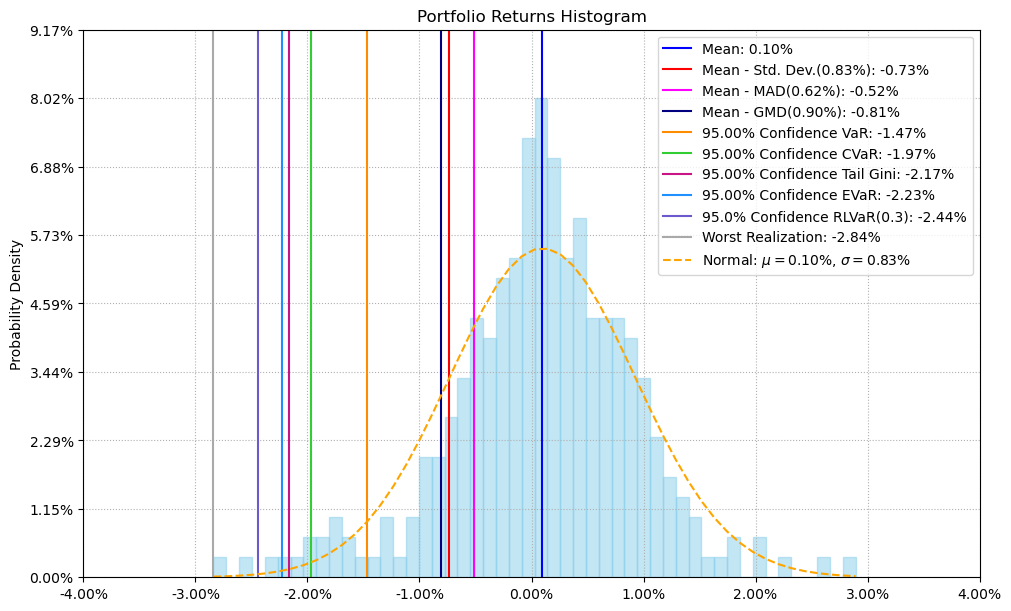

In [5]:
ax = rp.plot_hist(returns=Y,
                  w=w,
                  alpha=0.05,
                  bins=50,
                  height=6,
                  width=10,
                  ax=None)

### 2.4 Calculate efficient frontier

In [6]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
0,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,10.7448%,5.9778%,12.0963%,0.0000%,0.0000%,...,0.0000%,0.0000%,5.6314%,0.0000%,13.3045%,0.0000%,0.0000%,0.0000%,24.9235%,4.4624%
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,10.2979%,0.8492%,0.0000%,0.0000%,0.0000%,...,17.2893%,0.0000%,7.6387%,0.0000%,13.5214%,3.4902%,0.0000%,0.0000%,28.5946%,0.0000%
2,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,9.4343%,0.0000%,0.0000%,0.0000%,0.0000%,...,29.0088%,0.0000%,5.0636%,0.0000%,12.7365%,2.7075%,0.0000%,0.0000%,29.9013%,0.0000%
3,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,8.2735%,0.0000%,0.0000%,4.5193%,0.0000%,...,35.4858%,0.0000%,0.0000%,0.0000%,9.9570%,1.5239%,2.2022%,0.0000%,26.3974%,0.0000%
4,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,6.0971%,0.0000%,0.0000%,7.4524%,0.0000%,...,37.1222%,0.0000%,0.0000%,1.7246%,11.5070%,2.8289%,6.5133%,0.0000%,19.0816%,0.0000%


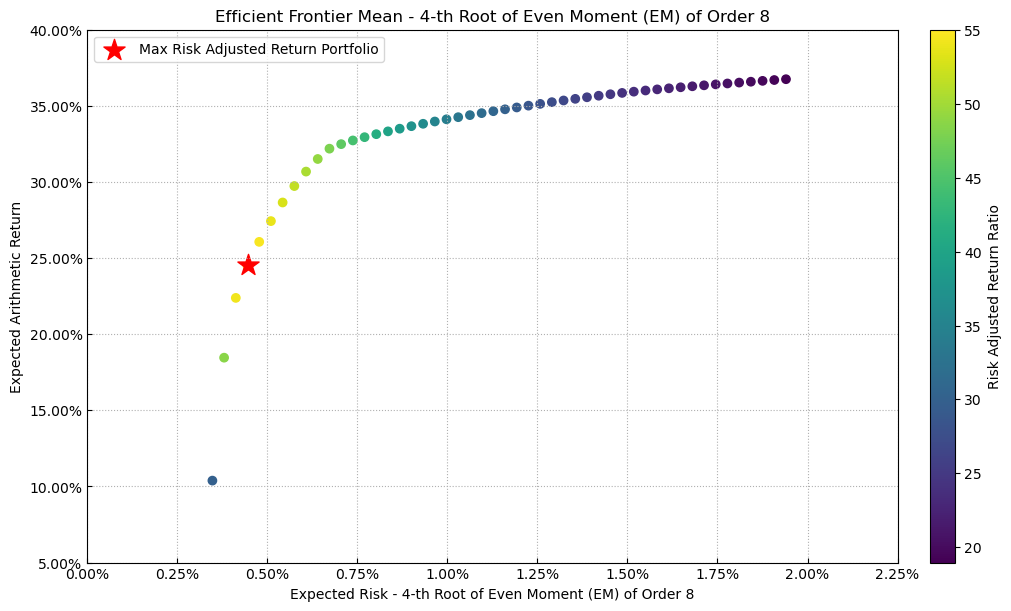

In [7]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    p_em=port.p_em,
    cmap='viridis',
    w=w,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)

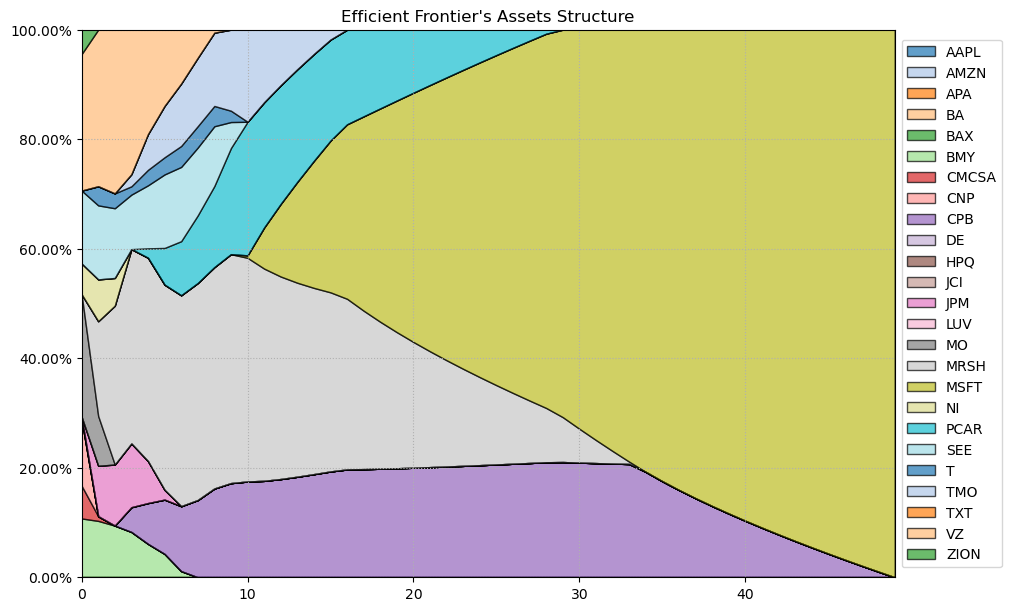

In [8]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

## 3. Estimating Risk Parity Portfolios for Even Moment of Order 2p

### 3.1 Calculating the risk parity portfolio for Even Moment of Order 2p

In [9]:
b = None # Risk contribution constraints vector

w_rp = port.rp_optimization(model=model, rm=rm, rf=rf, b=b, hist=hist)

display(w_rp.T)

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
weights,2.4218%,2.0736%,2.3871%,2.6152%,3.7191%,4.8317%,4.2453%,6.2383%,4.7408%,2.7639%,...,4.7600%,2.4939%,7.0399%,3.0588%,4.6012%,4.6779%,3.2989%,4.1216%,6.7127%,3.3081%


### 3.2 Plotting portfolio composition

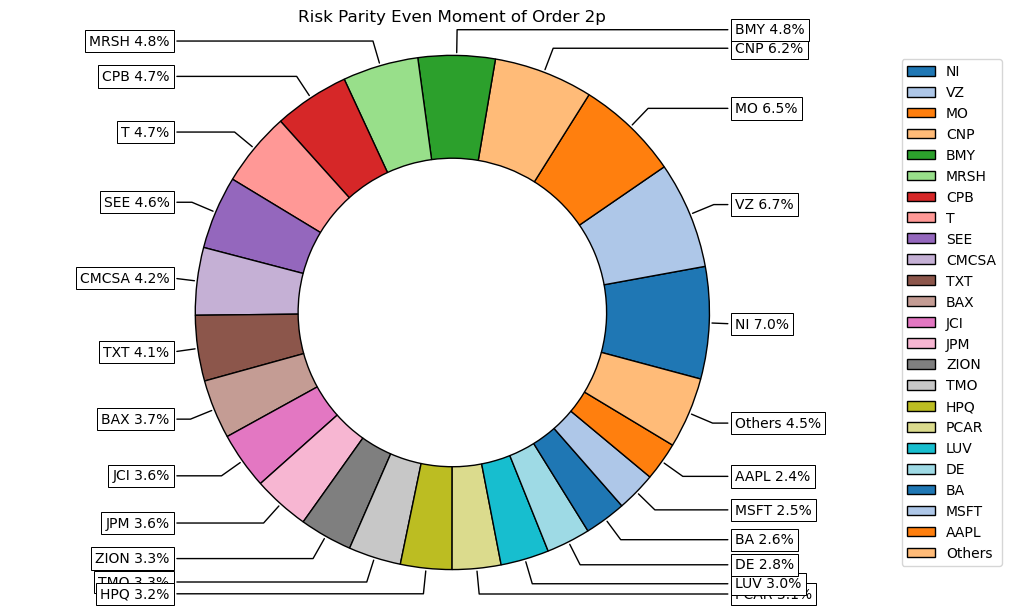

In [10]:
ax = rp.plot_pie(w=w_rp,
                 title='Risk Parity Even Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=6,
                 width=10,
                 ax=None)

### 3.3 Plotting Risk Composition

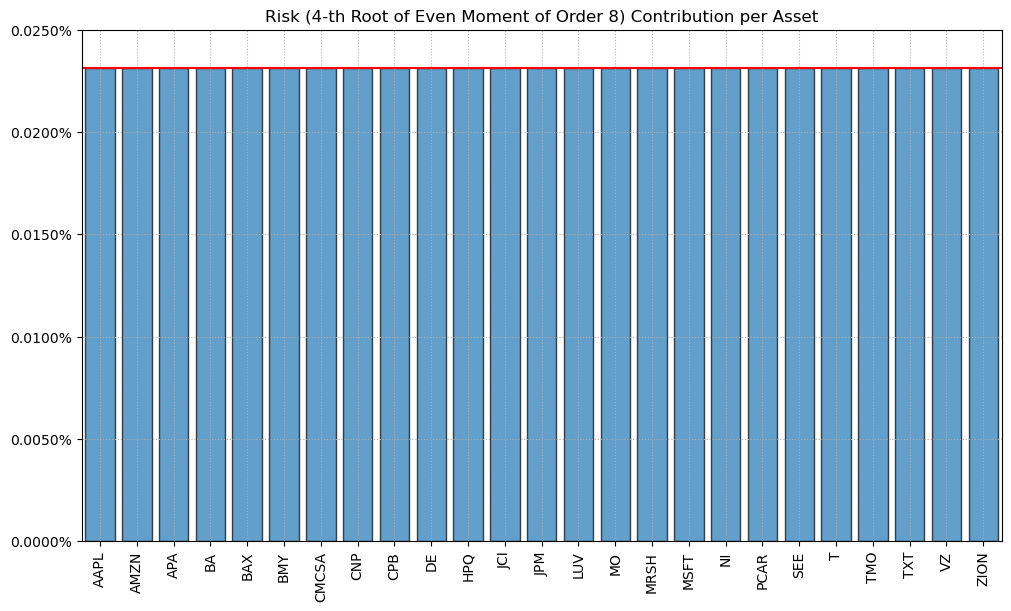

In [11]:
ax = rp.plot_risk_con(
    w=w_rp,
    cov=port.cov,
    returns=port.returns,
    rm=rm,
    rf=0,
    p_em=port.p_em,
    color="tab:blue",
    height=6,
    width=10,
    ax=None)

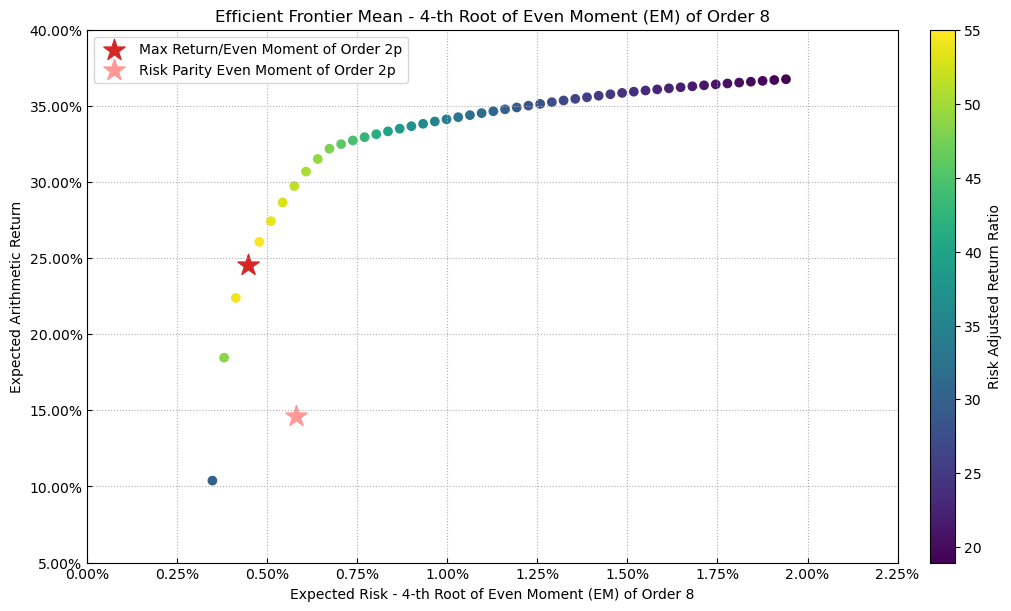

In [12]:
# Plotting the efficient frontier
ws = pd.concat([w, w_rp],axis=1)
ws.columns = ["Max Return/Even Moment of Order 2p", "Risk Parity Even Moment of Order 2p"]

mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    p_em=port.p_em,
    cmap='viridis',
    w=ws,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)
